# CDSD JAX 完整训练流程 - SAVAR 数据集

**JAX/Flax 版本特性：**
- ✅ JAX 自动微分和 JIT 编译
- ✅ GPU 支持（自动检测）
- ✅ Flax 神经网络模块
- ✅ Optax 优化器
- ✅ 从数据集自动读取参数
- ✅ 配置系统（方便多次实验）
- ✅ 完整的可视化

## 训练步骤：
1. 环境设置和配置
2. 数据加载（自动读取参数）
3. 模型初始化
4. 训练（ALM/QPM 约束优化）
5. 评估
6. 可视化

## 1. 环境设置

In [1]:
import os
os.environ["CDSD_DISABLE_PLOTS"]="1"

import sys

import json
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# ✅ 导入 CDSD JAX 模块（明确使用 cdsd_jax 前缀）
from cdsd_jax.data_loader_jax import DataLoaderJAX
from cdsd_jax.model.tsdcd_latent_jax import TSDCDConfig  # ← 改為 TSDCDConfig
from cdsd_jax.train_latent_jax import TrainingLatentJAX
from cdsd_jax.metrics_jax import mcc_latent, shd, precision_recall, edge_errors, w_mae

print(f"✓ JAX {jax.__version__}")
print(f"✓ Devices: {jax.devices()}")
print(f"✓ Default backend: {jax.default_backend()}")
print("✓ All CDSD JAX modules imported successfully!")

✓ JAX 0.7.2
✓ Devices: [CpuDevice(id=0)]
✓ Default backend: cpu
✓ All CDSD JAX modules imported successfully!


## 2. 配置参数

### 使用方式：
1. **快速开始**：直接运行，使用默认配置
2. **自定义实验**：修改 `CONFIG` 字典中的参数
3. **批量实验**：修改 `exp_id` 和其他参数，重复运行

In [2]:
# ==================== 实验配置 ====================
CONFIG = {
    # === 数据集 ===
    'data_path': "dataset/savar_N25_med-hard_seed0",
    'use_data_config': True,  # 是否从数据集自动读取 d_z, d_x, tau
    
    # === 实验输出 ===
    'exp_base_path': "cdsd_jax_results",
    'exp_name': "savar_N25_jax",
    'exp_id': 0,  # 实验编号（exp0, exp1, exp2, ...）
    
    # === 设备 ===
    'use_gpu': True,  # 自动检测并使用 GPU（如果可用）
    
    # === 训练超参数 ===
    'max_iteration': 50000,  # 完整训练用 50000-100000，快速测试用 5000-10000
    'patience': 5000,
    'patience_post_thresh': 80,
    'batch_size': 64,
    'lr': 0.001,
    'ratio_train': 0.8,
    'ratio_valid': 0.2,
    
    # === 模型架构 ===
    'num_hidden': 0,
    'num_layers': 0,
    'num_hidden_mixing': 0,
    'num_layers_mixing': 0,
    
    # === 正则化 ===
    'reg_coeff': 2e-4,
    'coeff_kl': 0.7,
    'schedule_reg': 0,
    'schedule_ortho': 0,
    
    # === 优化器 ===
    'optimizer': "rmsprop",
    'random_seed': 1,
    
    # === 日志频率 ===
    'valid_freq': 100,
    'print_freq': 1,
    'plot_freq': 10,
    
    # === ALM/QPM 约束优化 ===
    # 正交性约束（混合矩阵 W）
    'ortho_mu_init': 1e2,
    'ortho_mu_mult_factor': 1.2,
    'ortho_omega_gamma': 0.01,
    'ortho_omega_mu': 0.9,
    'ortho_h_threshold': 1e-4,
    'ortho_min_iter_convergence': 100,
    
    # 无环性约束（只在 instantaneous=True 时使用）
    'acyclic_mu_init': 1e1,
    'acyclic_mu_mult_factor': 2,
    'acyclic_omega_gamma': 0.01,
    'acyclic_omega_mu': 0.9,
    'acyclic_h_threshold': 1e-8,
    'acyclic_min_iter_convergence': 1000,
}

# 打印配置
print("Configuration:")
print(f"  Data: {CONFIG['data_path']}")
print(f"  Auto-read data config: {CONFIG['use_data_config']}")
# 检查 GPU 是否可用（安全方式）
try:
    gpu_available = len(jax.devices('gpu')) > 0
except RuntimeError:
    gpu_available = False

print(f"  Use GPU: {CONFIG['use_gpu']} (available: {gpu_available})")
print(f"  Max iterations: {CONFIG['max_iteration']}")
print(f"  Experiment: {CONFIG['exp_base_path']}/{CONFIG['exp_name']}/exp{CONFIG['exp_id']}")

Configuration:
  Data: dataset/savar_N25_med-hard_seed0
  Auto-read data config: True
  Use GPU: True (available: False)
  Max iterations: 50000
  Experiment: cdsd_jax_results/savar_N25_jax/exp0


## 3. 设置随机种子和实验目录

In [3]:
# 设置随机种子
np.random.seed(CONFIG['random_seed'])
rng_seed = CONFIG['random_seed']

# 创建实验目录
exp_path = os.path.join(
    CONFIG['exp_base_path'], 
    CONFIG['exp_name'], 
    f"exp{CONFIG['exp_id']}"
)
os.makedirs(exp_path, exist_ok=True)

print(f"✓ Random seed: {rng_seed}")
print(f"✓ Experiment directory: {exp_path}")

✓ Random seed: 1
✓ Experiment directory: cdsd_jax_results/savar_N25_jax/exp0


## 4. 载入数据（自动读取参数）

In [ ]:
print("Loading data...")

# 从数据集自动读取参数（如果启用）
if CONFIG['use_data_config']:
    data_params_path = os.path.join(CONFIG['data_path'], "data_params.json")
    if os.path.exists(data_params_path):
        with open(data_params_path, 'r') as f:
            data_params = json.load(f)
        
        d_x = data_params.get('d_x', 100)
        d_z = data_params.get('d_z', 25) if data_params.get('latent', True) else None
        tau = data_params.get('tau', 1)
        instantaneous = False  # SAVAR 固定使用 False
        
        print(f"✓ Auto-read from data_params.json:")
        print(f"  d_x = {d_x}")
        print(f"  d_z = {d_z}")
        print(f"  tau = {tau}")
    else:
        print("⚠ data_params.json not found, using defaults")
        d_x = 100
        d_z = 25
        tau = 1
        instantaneous = False
else:
    # 手动指定参数
    d_x = 100
    d_z = 25
    tau = 1
    instantaneous = False
    print("Using manual configuration")

# 加载数据
data_loader = DataLoaderJAX(
    ratio_train=CONFIG['ratio_train'],
    ratio_valid=CONFIG['ratio_valid'],
    data_path=CONFIG['data_path'],
    data_format="numpy",
    latent=True,
    no_gt=False,
    debug_gt_w=False,
    instantaneous=instantaneous,
    tau=tau,
    seed=CONFIG['random_seed']
)

print(f"\n✓ Data loaded successfully!")
print(f"  X shape: {data_loader.x.shape}")
print(f"  Z shape: {data_loader.z.shape if data_loader.z is not None else None}")
print(f"  Train samples: {data_loader.n_train}")
print(f"  Valid samples: {data_loader.n_valid}")
print(f"  GT graph shape: {data_loader.gt_graph.shape if data_loader.gt_graph is not None else None}")
print(f"  GT W shape: {data_loader.gt_w.shape if data_loader.gt_w is not None else None}")

Loading data...
✓ Auto-read from data_params.json:
  d_x = 100
  d_z = 25
  tau = 1

✓ Data loaded successfully!
  X shape: (1, 2000, 1, 100)
  Z shape: (1, 2000, 1, 25)
  Train samples: 1580
  Valid samples: 400
  GT graph shape: (1, 25, 25)
  GT W shape: (1, 100, 25)


## 5. 初始化模型

In [5]:
print("Initializing model...")

d = data_loader.x.shape[2]

model = TSDCDConfig(  # ← 改為 TSDCDConfig
    d=d,
    d_x=d_x,
    d_z=d_z,
    tau=tau,
    num_layers=CONFIG['num_layers'],
    num_hidden=CONFIG['num_hidden'],
    num_layers_mixing=CONFIG['num_layers_mixing'],
    num_hidden_mixing=CONFIG['num_hidden_mixing'],
    coeff_kl=CONFIG['coeff_kl'],
    instantaneous=instantaneous,
    nonlinear_mixing=False,
    hard_gumbel=True,
    tied_w=False
)

print(f"\n✓ Model config initialized!")
print(f"  Model: TSDCDConfig (Functional JAX)")  # ← 更新說明
print(f"  d={d}, d_x={d_x}, d_z={d_z}, tau={tau}")

Initializing model...

✓ Model config initialized!
  Model: TSDCDConfig (Functional JAX)
  d=1, d_x=100, d_z=25, tau=1


## 6. 准备训练器

In [6]:
print("Setting up trainer...")

# 创建超参数对象
class HParams:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

hp = HParams(
    # 数据相关
    latent=True,
    no_gt=False,
    debug_gt_z=False,
    d_z=d_z,
    d_x=d_x,
    tau=tau,
    instantaneous=instantaneous,
    no_w_constraint=False,
    
    # 训练相关
    batch_size=CONFIG['batch_size'],
    max_iteration=CONFIG['max_iteration'],
    patience=CONFIG['patience'],
    patience_post_thresh=CONFIG['patience_post_thresh'],
    
    # 优化器
    optimizer=CONFIG['optimizer'],
    lr=CONFIG['lr'],
    
    # 正则化
    reg_coeff=CONFIG['reg_coeff'],
    schedule_reg=CONFIG['schedule_reg'],
    schedule_ortho=CONFIG['schedule_ortho'],
    
    # ALM/QPM - 正交性约束
    ortho_mu_init=CONFIG['ortho_mu_init'],
    ortho_mu_mult_factor=CONFIG['ortho_mu_mult_factor'],
    ortho_omega_gamma=CONFIG['ortho_omega_gamma'],
    ortho_omega_mu=CONFIG['ortho_omega_mu'],
    ortho_h_threshold=CONFIG['ortho_h_threshold'],
    ortho_min_iter_convergence=CONFIG['ortho_min_iter_convergence'],
    
    # ALM/QPM - 无环性约束
    acyclic_mu_init=CONFIG['acyclic_mu_init'],
    acyclic_mu_mult_factor=CONFIG['acyclic_mu_mult_factor'],
    acyclic_omega_gamma=CONFIG['acyclic_omega_gamma'],
    acyclic_omega_mu=CONFIG['acyclic_omega_mu'],
    acyclic_h_threshold=CONFIG['acyclic_h_threshold'],
    acyclic_min_iter_convergence=CONFIG['acyclic_min_iter_convergence'],
    
    # 日志
    valid_freq=CONFIG['valid_freq'],
    print_freq=CONFIG['print_freq'],
    plot_freq=CONFIG['plot_freq'],
    graph_history_limit=50,
    plot_through_time=False,
    exp_path=exp_path,
)

# 载入 best_metrics
best_metrics_path = os.path.join(CONFIG['data_path'], 'best_metrics.json')
if os.path.exists(best_metrics_path):
    with open(best_metrics_path, 'r') as f:
        best_metrics = json.load(f)
else:
    # 使用默认值
    best_metrics = {
        "shd": 0.0,
        "mcc": 0.0,
        "recons": 0.0,
        "kl": 0.0,
        "elbo": 0.0
    }
    print("⚠ best_metrics.json not found, using defaults")

# 创建训练器
trainer = TrainingLatentJAX(
    model=model,
    data=data_loader,
    hp=hp,
    best_metrics=best_metrics,
    rng_seed=rng_seed
)

print("\n✓ Trainer ready!")
print(f"  Using TrainingLatentJAX with ALM/QPM constraints")

Setting up trainer...
Plotting disabled: CDSD_DISABLE_PLOTS is set

=== JIT Shape Validation ===
d = 1, d_z = 25, d_x = 100
d * d_z = 25 (用于 DAG constraint reshape)
Adjacency matrix shape: (2, 25, 25)
✓ Shape validation passed: 25 * 25 = 625


✓ Trainer ready!
  Using TrainingLatentJAX with ALM/QPM constraints


## 7. 开始训练

完整的训练流程包括：
1. **ALM/QPM 优化阶段**：优化正交性约束
2. **继续训练阶段**：直到验证损失稳定
3. **阈值化阶段**：将邻接矩阵二值化
4. **微调阶段**：在固定图结构下微调参数

In [ ]:
print("\n" + "="*70)
print("Starting Training with ALM/QPM Constraint Optimization (JAX)")
print("="*70)
print(f"Max iterations: {CONFIG['max_iteration']}")
print(f"Validation every {CONFIG['valid_freq']} iterations")
print(f"Patience: {CONFIG['patience']}")
print(f"Device: {jax.default_backend().upper()}")
print("="*70 + "\n")

t0 = time.time()

# 完整的训练流程
valid_loss = trainer.train_with_QPM()

training_time = time.time() - t0

print("\n" + "="*70)
print(f"✓ Training completed!")
print(f"  Total time: {training_time:.2f}s ({training_time/60:.2f} minutes)")
print(f"  Iterations: {trainer.iteration}")
print(f"  Converged: {trainer.converged}")
print(f"  Thresholded: {trainer.thresholded}")
print("="*70)


Starting Training with ALM/QPM Constraint Optimization (JAX)
Max iterations: 50000
Validation every 100 iterations
Patience: 5000
Device: CPU

Iteration #100
Converged: False
ELBO: -267.1401
Recons: -156.5136
KL: 158.0380
Sparsity_reg: 1.2e-01
ortho cons: 3.2e-02
ortho mu: 100.0
acyclic cons: 0.0000
acyclic mu: 10.0
-------------------------------
valid_ELBO: -259.7194
patience: 5000
Iteration #200
Converged: False
ELBO: -226.7171
Recons: -144.5494
KL: 117.3824
Sparsity_reg: 1.2e-01
ortho cons: 4.5e-02
ortho mu: 100.0
acyclic cons: 0.0000
acyclic mu: 10.0
-------------------------------
valid_ELBO: -222.1892
patience: 5000
Iteration #300
Converged: False
ELBO: -194.8410
Recons: -128.7923
KL: 94.3553
Sparsity_reg: 1.2e-01
ortho cons: 5.4e-02
ortho mu: 100.0
acyclic cons: 0.0000
acyclic mu: 10.0
-------------------------------
valid_ELBO: -197.1960
patience: 5000
Iteration #400
Converged: False
ELBO: -176.6398
Recons: -123.8264
KL: 75.4478
Sparsity_reg: 1.2e-01
ortho cons: 6.0e-02
ortho

Exception ignored in: <function _xla_gc_callback at 0x106ba65c0>
Traceback (most recent call last):
  File "/Users/andyhou/.local/share/mamba/envs/causal_inference/lib/python3.11/site-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Iteration #3400
Converged: False
ELBO: 65.0504
Recons: 81.5694
KL: 23.5986
Sparsity_reg: 1.1e-01
ortho cons: 1.5e-01
ortho mu: 1283.9184645488635
acyclic cons: 0.0000
acyclic mu: 40960.0
-------------------------------
valid_ELBO: 65.8166
patience: 5000


## 8. 评估结果

In [ ]:
print("\nEvaluating results...")

# 获取学习的图
gt_graph = trainer.gt_dag
learned_graph = np.array(trainer.get_adj())
# learned_adj_prob = np.array(trainer.get_adj())

# THRESHOLD = 0.5
# learned_graph = (learned_adj_prob > THRESHOLD).astype(np.float32)
# ================================

learned_graph = learned_graph.reshape(gt_graph.shape[0], gt_graph.shape[1], -1)

learned_graph = learned_graph.reshape(gt_graph.shape[0], gt_graph.shape[1], -1)

# 计算 MCC 和潜变量对应
score, cc_program_perm, assignments, z, z_hat, _ = mcc_latent(
    trainer,
    trainer.data,
    num_samples=int(1e5),
    rng=trainer.rng  # Pass RNG for encode() calls
)

# 根据学习到的潜变量排列重新排列 ground truth
permutation = np.zeros((gt_graph.shape[1], gt_graph.shape[1]))
permutation[np.arange(gt_graph.shape[1]), assignments[1]] = 1
gt_graph_permuted = permutation.T @ gt_graph @ permutation

# 计算所有评估指标
learned_w = np.array(trainer.get_w_decoder())
metrics = {
    'mcc': float(score),
    'w_mae': float(w_mae(
        learned_w[:, :, assignments[1]], 
        data_loader.gt_w
    )),
    'shd': float(shd(learned_graph, gt_graph_permuted)),
    'training_time': training_time,
    'n_iterations': int(trainer.iteration),
    'converged': bool(trainer.converged),
    'thresholded': bool(trainer.thresholded),
}

prec, rec = precision_recall(learned_graph, gt_graph_permuted)
metrics['precision'] = float(prec)
metrics['recall'] = float(rec)

errors = edge_errors(learned_graph, gt_graph_permuted)
metrics.update(errors)
metrics.update(valid_loss)

# 添加边统计量
metrics['n_edge_gt_graph'] = float(np.sum(gt_graph_permuted))
metrics['n_edge_learned_graph'] = float(np.sum(learned_graph))

print("\n" + "="*70)
print("Causal Structure Evaluation")
print("="*70)
print(f"MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"SHD (graph distance):   {metrics['shd']:.1f}")
print(f"Precision:              {metrics['precision']:.4f}")
print(f"Recall:                 {metrics['recall']:.4f}")
print(f"W MAE:                  {metrics['w_mae']:.4f}")
print(f"\nTrue Positives:  {metrics['tp']}")
print(f"False Positives: {metrics['fp']}")
print(f"True Negatives:  {metrics['tn']}")
print(f"False Negatives: {metrics['fn']}")
print(f"\nGT edges:      {metrics['n_edge_gt_graph']:.0f}")
print(f"Learned edges: {metrics['n_edge_learned_graph']:.0f}")
print("="*70)


Evaluating results...

Causal Structure Evaluation
MCC (latent recovery):  0.8481
SHD (graph distance):   21.0
Precision:              0.8293
Recall:                 0.9067
W MAE:                  0.0102

True Positives:  68.0
False Positives: 14.0
True Negatives:  536.0
False Negatives: 7.0

GT edges:      75
Learned edges: 82


In [ ]:
adj_prob = np.array(trainer.get_adj())
print("adj prob stats: min", adj_prob.min(), "max", adj_prob.max(), "mean", adj_prob.mean())

w_dec = np.array(trainer.get_w_decoder())
print("W decoder stats: min", w_dec.min(), "max", w_dec.max(), "mean", w_dec.mean())

print("tail h_acyclic:", trainer.valid_acyclic_cons_list[-5:])
print("tail h_ortho:", [float(jnp.sum(h)) for h in trainer.valid_ortho_cons_list[-5:]])
print("mu_ortho:", trainer.ALM_ortho.state.mu)
if trainer.instantaneous:
    print("mu_acyclic:", trainer.QPM_acyclic.state.mu)

adj prob stats: min 0.0 max 1.0 mean 0.1312
W decoder stats: min 0.0 max 0.7561669 mean 0.019699449
tail h_acyclic: [0.0, 0.0, 0.0, 0.0, 0.0]
tail h_ortho: [0.006908945739269257, 0.006067769601941109, 0.005709207616746426, 0.0054463488049805164, 0.0074811833910644054]
mu_ortho: 3260851.5250675157


In [ ]:
@jax.jit
def _compute_metrics_pure(y, y_pred):
    """
    純函數：計算 MSE 和 SMAPE (JIT 編譯加速)
    y, y_pred shape: (batch, d, d_x)
    """
    # MSE: 0.5 * (y - y_pred)^2 的平均
    # axis=2 對應 PyTorch 的 dim=2 (d_x 維度)
    mse = jnp.mean(jnp.sum(0.5 * (y - y_pred) ** 2, axis=2))

    # SMAPE: 2 * |y - y_pred| / (|y| + |y_pred|) 的平均
    numerator = 2 * jnp.abs(y - y_pred)
    denominator = jnp.abs(y) + jnp.abs(y_pred) + 1e-8
    smape = jnp.mean(jnp.sum(numerator / denominator, axis=2))

    return mse, smape

def calculate_prediction_error(trainer, valid=False, max_samples=1000):
    """
    JAX 版本：计算 X_{t+1} 和 X_hat_{t+1} 之间的 MSE 和 SMAPE
    """
    # 1. 管理隨機鑰匙 (JAX 需要顯式處理 RNG)
    # 分裂 trainer 的 rng，一個用於數據採樣，一個用於模型前向傳播
    rng = trainer.rng
    rng, key_sample, key_forward = jax.random.split(rng, 3)
    trainer.rng = rng  # 更新 trainer 的 rng 狀態

    # 2. 數據採樣
    if not valid:
        bs = min(trainer.data.n_train, max_samples)
        # 假設您的 JAX DataLoader 支援傳入 rng
        x, y, _ = trainer.data.sample(bs, valid=False, rng=key_sample)
    else:
        bs = min(trainer.data.n_valid, max_samples)
        x, y, _ = trainer.data.sample(bs, valid=True, rng=key_sample)

    # 3. 獲取預測 (Functional Call)
    # 使用 trainer.state.apply_fn 執行前向傳播
    # deterministic=True 類似於 PyTorch 的 model.eval()，關閉 Dropout 等隨機性
    output = trainer.state.apply_fn(
        trainer.state.params, 
        x, 
        y, 
        key_forward, 
        deterministic=True
    )
    
    # 提取預測值 (px_mu 對應 reconstruction mean)
    y_pred = output['px_mu']

    # 4. 計算指標
    mse, smape = _compute_metrics_pure(y, y_pred)

    # 轉回 Python float
    return float(mse), float(smape)

# ==========================================
# 執行評估
# ==========================================

print("\n" + "="*70)
print("Prediction Error Evaluation")
print("="*70)

# 训练集预测误差
train_mse, train_smape = calculate_prediction_error(trainer, valid=False)
print(f"Train MSE:   {train_mse:.6f}")
print(f"Train SMAPE: {train_smape:.6f}")

# 验证集预测误差
val_mse, val_smape = calculate_prediction_error(trainer, valid=True)
print(f"Val MSE:     {val_mse:.6f}")
print(f"Val SMAPE:   {val_smape:.6f}")
print("="*70)

# 添加到 metrics 字典 (假設 metrics 已經定義)
# metrics['train_mse'] = train_mse
# metrics['train_smape'] = train_smape
# metrics['val_mse'] = val_mse
# metrics['val_smape'] = val_smape

print("\n✓ Prediction errors calculated")


Prediction Error Evaluation
Train MSE:   2.950043
Train SMAPE: 100.958969
Val MSE:     3.307040
Val SMAPE:   100.392853

✓ Prediction errors calculated


## 9. 保存结果

In [ ]:
# 保存完整的评估结果
with open(os.path.join(exp_path, "results.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# 保存配置参数
config_to_save = CONFIG.copy()
config_to_save['d_z'] = d_z
config_to_save['d_x'] = d_x
config_to_save['tau'] = tau
config_to_save['instantaneous'] = instantaneous
config_to_save['device'] = jax.default_backend()

with open(os.path.join(exp_path, "config.json"), "w") as f:
    json.dump(config_to_save, f, indent=4)

print(f"\n✓ Results and config saved to: {exp_path}/")
print(f"  - results.json (评估指标)")
print(f"  - config.json (完整配置)")


✓ Results and config saved to: cdsd_jax_results/savar_N25_jax/exp0/
  - results.json (评估指标)
  - config.json (完整配置)


## 10. 可视化：训练曲线

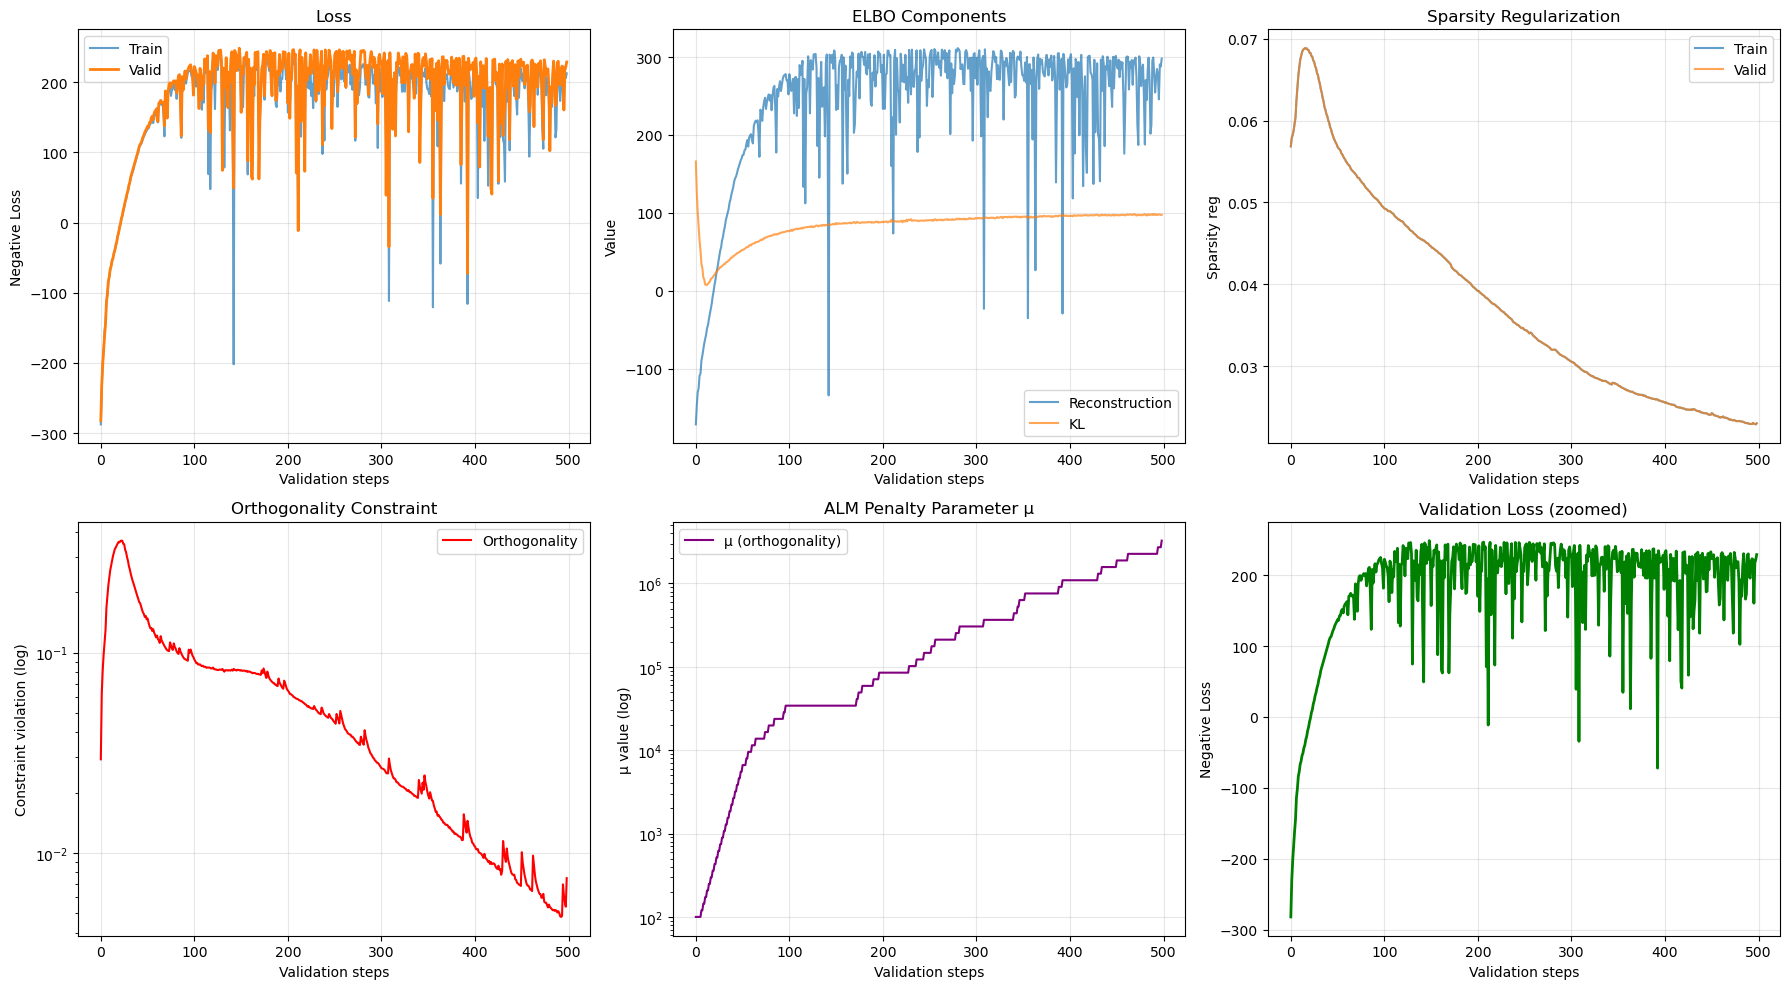

✓ Training curves saved to cdsd_jax_results/savar_N25_jax/exp0/training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(trainer.train_loss_list, label='Train', alpha=0.7)
axes[0, 0].plot(trainer.valid_loss_list, label='Valid', linewidth=2)
axes[0, 0].set_xlabel('Validation steps')
axes[0, 0].set_ylabel('Negative Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ELBO components
axes[0, 1].plot(trainer.train_recons_list, label='Reconstruction', alpha=0.7)
axes[0, 1].plot(trainer.train_kl_list, label='KL', alpha=0.7)
axes[0, 1].set_xlabel('Validation steps')
axes[0, 1].set_ylabel('Value')
axes[0, 1].set_title('ELBO Components')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Sparsity regularization
axes[0, 2].plot(trainer.train_sparsity_reg_list, label='Train', alpha=0.7)
axes[0, 2].plot(trainer.valid_sparsity_reg_list, label='Valid', alpha=0.7)
axes[0, 2].set_xlabel('Validation steps')
axes[0, 2].set_ylabel('Sparsity reg')
axes[0, 2].set_title('Sparsity Regularization')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Orthogonality constraint violation
ortho_cons = [float(np.sum(c)) for c in trainer.train_ortho_vector_cons_list]
axes[1, 0].semilogy(ortho_cons, label='Orthogonality', color='red')
axes[1, 0].set_xlabel('Validation steps')
axes[1, 0].set_ylabel('Constraint violation (log)')
axes[1, 0].set_title('Orthogonality Constraint')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Mu (penalty parameter)
axes[1, 1].semilogy(trainer.mu_ortho_list, label='μ (orthogonality)', color='purple')
axes[1, 1].set_xlabel('Validation steps')
axes[1, 1].set_ylabel('μ value (log)')
axes[1, 1].set_title('ALM Penalty Parameter μ')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Valid loss zoomed
axes[1, 2].plot(trainer.valid_loss_list, linewidth=2, color='green')
axes[1, 2].set_xlabel('Validation steps')
axes[1, 2].set_ylabel('Negative Loss')
axes[1, 2].set_title('Validation Loss (zoomed)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved to {exp_path}/training_curves.png")

## 11. 可视化：学习的图 vs Ground Truth

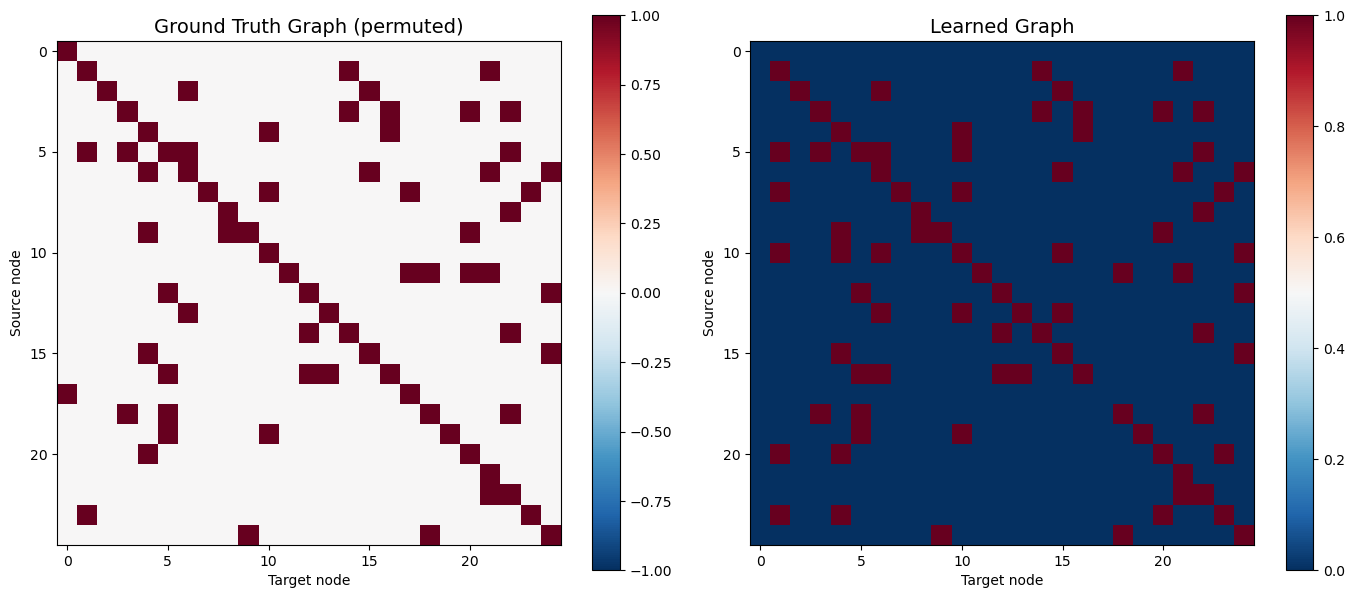

✓ Graph comparison saved to cdsd_jax_results/savar_N25_jax/exp0/learned_vs_gt_graph.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground Truth (permuted)
im1 = axes[0].imshow(gt_graph_permuted[0], cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Ground Truth Graph (permuted)', fontsize=14)
axes[0].set_xlabel('Target node')
axes[0].set_ylabel('Source node')
plt.colorbar(im1, ax=axes[0])

# Learned
im2 = axes[1].imshow(learned_graph[0], cmap='RdBu_r', vmin=0, vmax=1)
axes[1].set_title('Learned Graph', fontsize=14)
axes[1].set_xlabel('Target node')
axes[1].set_ylabel('Source node')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'learned_vs_gt_graph.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Graph comparison saved to {exp_path}/learned_vs_gt_graph.png")

## 12. 可视化：混合矩阵 W

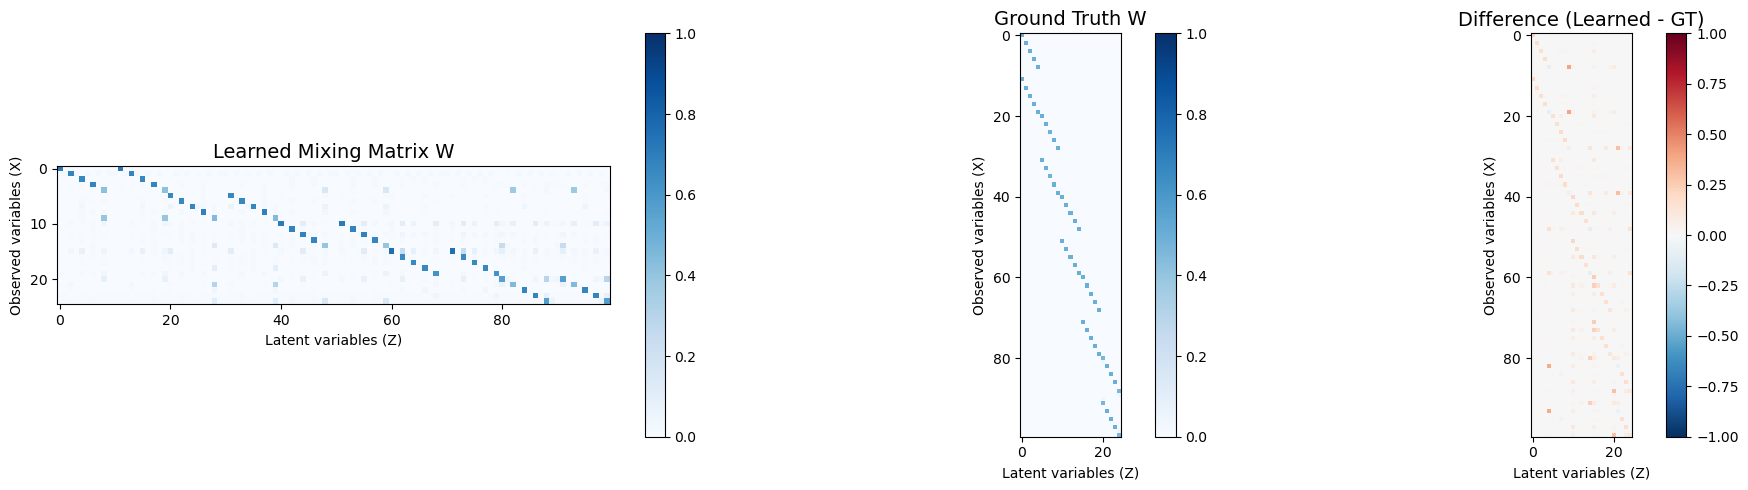

✓ Mixing matrix W saved to cdsd_jax_results/savar_N25_jax/exp0/mixing_matrix_w.png


In [ ]:
# 获取学习的混合矩阵
gt_w = data_loader.gt_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learned W
im1 = axes[0].imshow(learned_w[0, :, assignments[1]], cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Learned Mixing Matrix W', fontsize=14)
axes[0].set_xlabel('Latent variables (Z)')
axes[0].set_ylabel('Observed variables (X)')
plt.colorbar(im1, ax=axes[0])

# Ground Truth W
im2 = axes[1].imshow(gt_w[0], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Ground Truth W', fontsize=14)
axes[1].set_xlabel('Latent variables (Z)')
axes[1].set_ylabel('Observed variables (X)')
plt.colorbar(im2, ax=axes[1])

# Difference
diff_w = learned_w[0, :, assignments[1]].T - gt_w[0] 
im3 = axes[2].imshow(diff_w, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_title('Difference (Learned - GT)', fontsize=14)
axes[2].set_xlabel('Latent variables (Z)')
axes[2].set_ylabel('Observed variables (X)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'mixing_matrix_w.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Mixing matrix W saved to {exp_path}/mixing_matrix_w.png")

## 13. 完整结果总结

In [ ]:
print("\n" + "="*70)
print("COMPLETE RESULTS SUMMARY (JAX)")
print("="*70)

print("\n📊 Causal Structure Discovery:")
print(f"  MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"  SHD (graph distance):   {metrics['shd']:.1f}")
print(f"  Precision:              {metrics['precision']:.4f}")
print(f"  Recall:                 {metrics['recall']:.4f}")
print(f"  W MAE:                  {metrics['w_mae']:.4f}")

print("\n⚙️ Training Info:")
print(f"  Time:       {training_time:.2f}s ({training_time/60:.2f} min)")
print(f"  Iterations: {trainer.iteration}")
print(f"  Device:     {jax.default_backend().upper()}")
print(f"  Framework:  JAX/Flax")

print("\n💾 Saved Files:")
print(f"  {exp_path}/")
print(f"    - results.json (完整评估指标)")
print(f"    - config.json (实验配置)")
print(f"    - training_curves.png")
print(f"    - learned_vs_gt_graph.png")
print(f"    - mixing_matrix_w.png")

print("\n" + "="*70)
print("✓ ALL DONE!")
print("="*70)


COMPLETE RESULTS SUMMARY (JAX)

📊 Causal Structure Discovery:
  MCC (latent recovery):  0.8481
  SHD (graph distance):   21.0
  Precision:              0.8293
  Recall:                 0.9067
  W MAE:                  0.0102

⚙️ Training Info:
  Time:       555.30s (9.26 min)
  Iterations: 50000
  Device:     CPU
  Framework:  JAX/Flax

💾 Saved Files:
  cdsd_jax_results/savar_N25_jax/exp0/
    - results.json (完整评估指标)
    - config.json (实验配置)
    - training_curves.png
    - learned_vs_gt_graph.png
    - mixing_matrix_w.png

✓ ALL DONE!
